# House Price Prediction using Linear Regression
**Author:** @VedantAndhale

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

pd.set_option("display.float_format", "{:,.2f}".format)

## 1. Load the Dataset

In [28]:
url = "https://raw.githubusercontent.com/huzaifsayed/Linear-Regression-Model-for-House-Price-Prediction/master/USA_Housing.csv"
df = pd.read_csv(url)
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,"79,545.46",5.68,7.01,4.09,"23,086.80","1,059,033.56","208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,"79,248.64",6.00,6.73,3.09,"40,173.07","1,505,890.91","188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,"61,287.07",5.87,8.51,5.13,"36,882.16","1,058,987.99","9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,"63,345.24",7.19,5.59,3.26,"34,310.24","1,260,616.81",USS Barnett\nFPO AP 44820
4,"59,982.20",5.04,7.84,4.23,"26,354.11","630,943.49",USNS Raymond\nFPO AE 09386


## 2. Explore the Dataset

In [29]:
print("Missing values in each column:")
print(df.isnull().sum())
df.describe()  # Statistical summary of the dataset

Missing values in each column:
Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,"5,000.00","5,000.00","5,000.00","5,000.00","5,000.00","5,000.00"
mean,"68,583.11",5.98,6.99,3.98,"36,163.52","1,232,072.65"
std,"10,657.99",0.99,1.01,1.23,"9,925.65","353,117.63"
min,"17,796.63",2.64,3.24,2.00,172.61,"15,938.66"
25%,"61,480.56",5.32,6.30,3.14,"29,403.93","997,577.14"
50%,"68,804.29",5.97,7.00,4.05,"36,199.41","1,232,669.38"
75%,"75,783.34",6.65,7.67,4.49,"42,861.29","1,471,210.20"
max,"107,701.75",9.52,10.76,6.50,"69,621.71","2,469,065.59"


## 3. Prepare the Data

In [30]:
X = df.drop(["Price", "Address"], axis=1)
y = df["Price"]
X.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population
0,"79,545.46",5.68,7.01,4.09,"23,086.80"
1,"79,248.64",6.00,6.73,3.09,"40,173.07"
2,"61,287.07",5.87,8.51,5.13,"36,882.16"
3,"63,345.24",7.19,5.59,3.26,"34,310.24"
4,"59,982.20",5.04,7.84,4.23,"26,354.11"


## 4. Split the Data

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 4000
Testing samples: 1000


## 5. Train the Linear Regression Model

In [32]:
model = LinearRegression()
model.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


## 6. Make Predictions

In [33]:
y_pred = model.predict(X_test)
y_pred[:5]  # Show first 5 predictions

array([1308587.92699731, 1237037.22949408, 1243429.34030707,
       1228900.21360412, 1063320.90710778])

## 7. Evaluate the Model

In [34]:
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")

Mean Squared Error: 10089009300.89


## 8. Visualize the Results

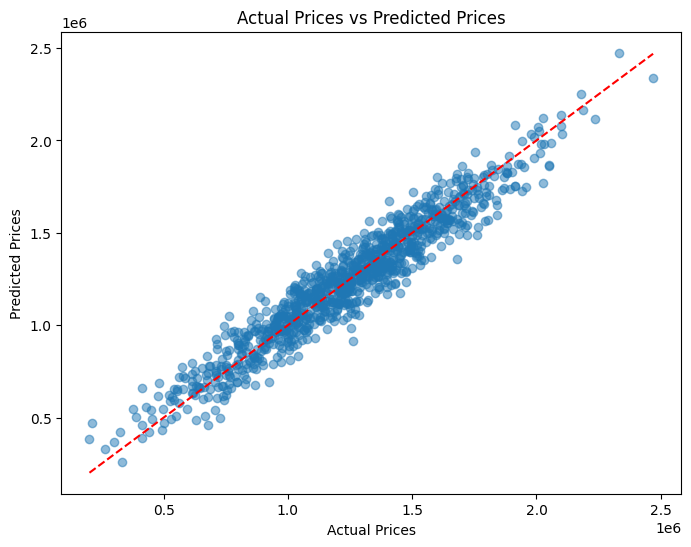

In [35]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual Prices vs Predicted Prices")
plt.plot(
    [y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--"
)  # Line for perfect prediction
plt.show()

## 9. Predict the Price for a Single House

In [36]:
new_house = pd.DataFrame(
    {
        "Avg. Area Income": [60000],
        "Avg. Area House Age": [5],
        "Avg. Area Number of Rooms": [7],
        "Avg. Area Number of Bedrooms": [4],
        "Area Population": [40000],
    }
)

predicted_price = model.predict(new_house)
print(f"Estimated price for the house: ${predicted_price[0]:,.2f}")

Estimated price for the house: $945,333.98
